### Exploring BaseNILM package

----------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------
Welcome to BaseNILM: A toolkit for energy disaggregation
Mode:       Simulation
Author:     Dr. Pascal A. Schirmer
Copyright:  Pascal Schirmer
Version:    v.0.2
Date:       21.11.2023
----------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------
START: BaseNILM 1-fold simulation
------------------------------------------
START: Loading testing data
------------------------------------------
INFO: Loading Dataset
INFO: Loading dataset from sub-folder: \data\ ampds
INFO: 3D datafile loaded using axis: 0
INFO: Mat data file loaded
INFO: Output features selected
INFO: Data limited to  525600  samples
INFO: Loading Dataset
INFO: Lo

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_115 (Conv1D)             │ (None, 20, 30)         │         1,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_116 (Conv1D)             │ (None, 20, 30)         │         7,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_117 (Conv1D)             │ (None, 20, 40)         │         7,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_118 (Conv1D)             │ (None, 20, 50)         │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_119 (Conv1D)             │ (None, 20, 50)         │        12,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 4, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 256)            │        51,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,625 (869.63 KB)

 Trainable params: 222,625 (869.63 KB)

 Non-trainable params: 0 (0.00 B)

ERROR: Model could not be loaded
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
INFO: Total inference time (ms): 5531.85
INFO: Inference time per sample (us): 63.16
INFO: Model size (kB): 0.01


------------------------------------------
START: Postprocessing
------------------------------------------
INFO: Start Postprocessing Prediction
INFO: Normalise data
INFO: Input Avg/Sig normalisation
INFO: Output 0/1 normalisation
INFO: Normalise data
INFO: Input Avg/Sig normalisation
INFO: Output 0/1 normalisation


------------------------------------------
START: Output
------------------------------------------
INFO: Calculating Performance
INFO: Ranking Input Features
INFO: Running Feature Ranking
INFO: Printing results on console
INFO: Simulation completed with 0 low priority and 0 high priority warnings
INFO: List of low priority warnings includes:
INFO: List of high priority warnings includes:
INFO: Printing accuracy results
-----------------------------------------------------------------

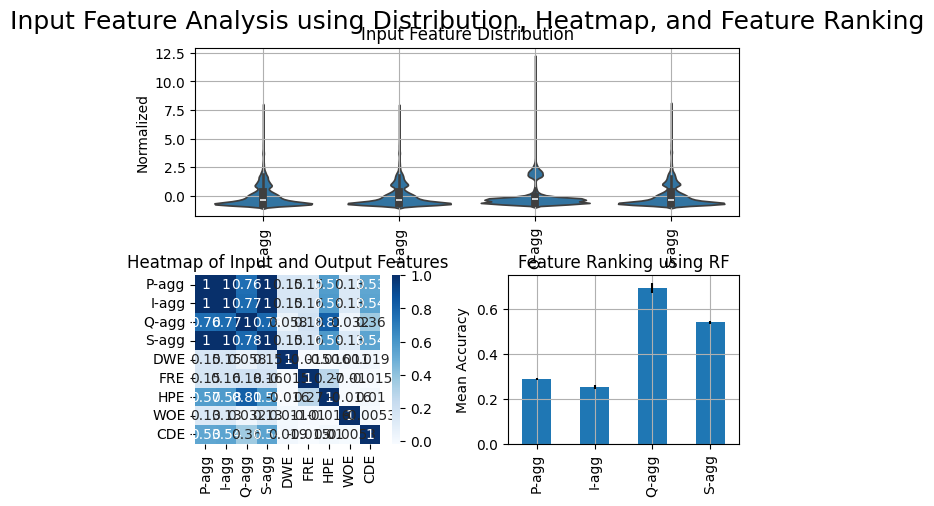

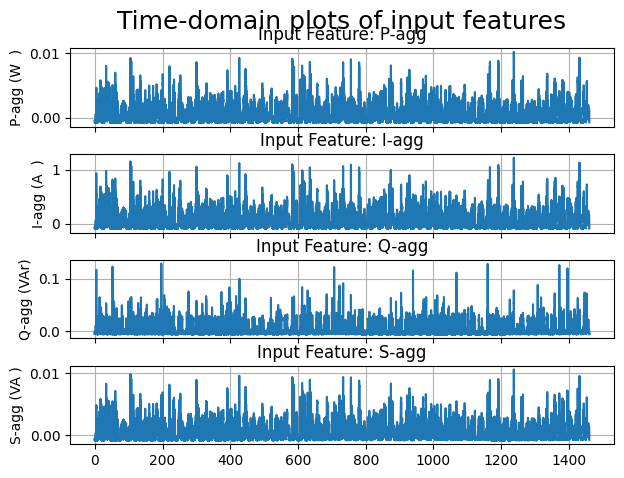

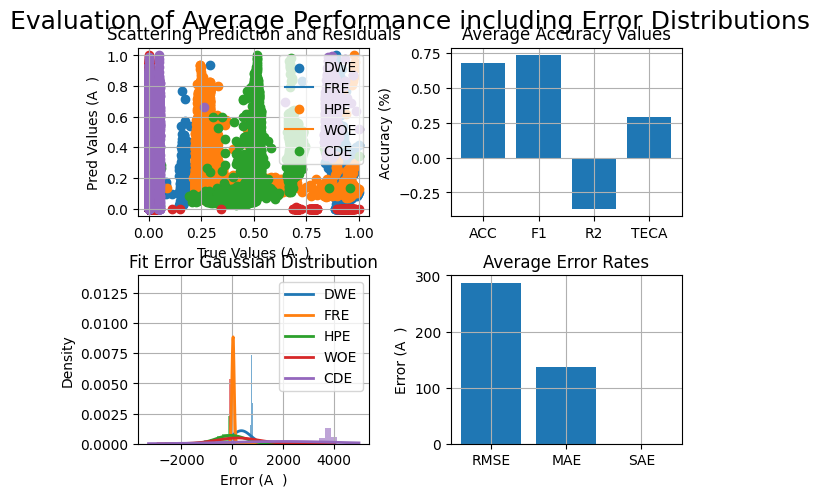

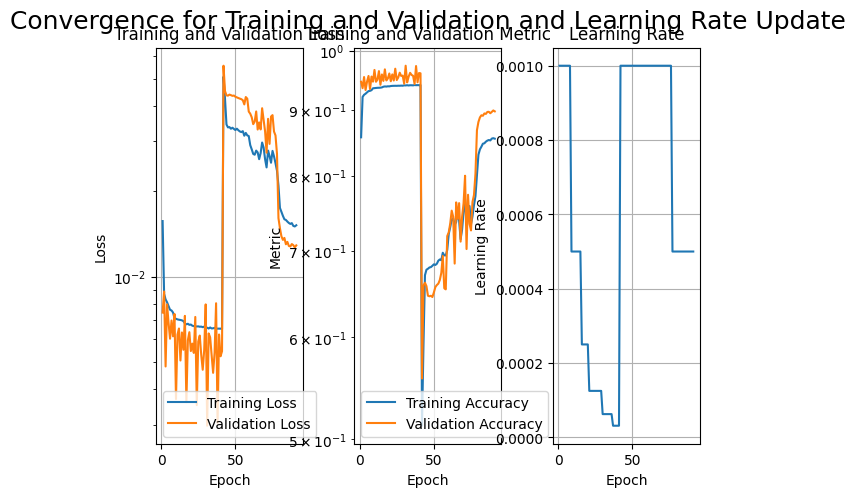

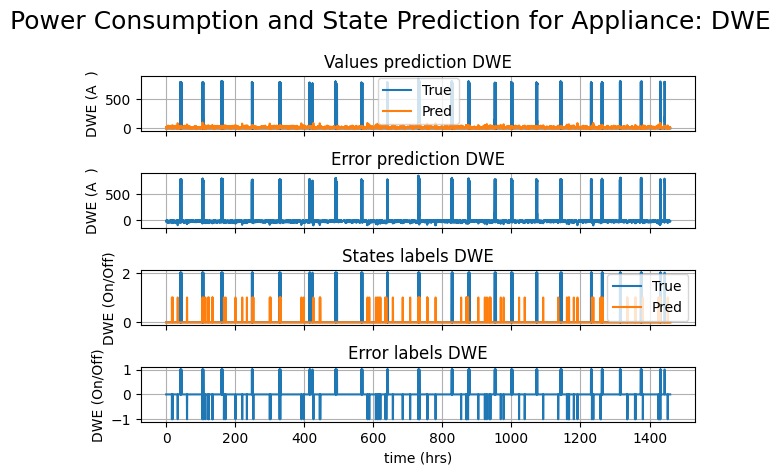

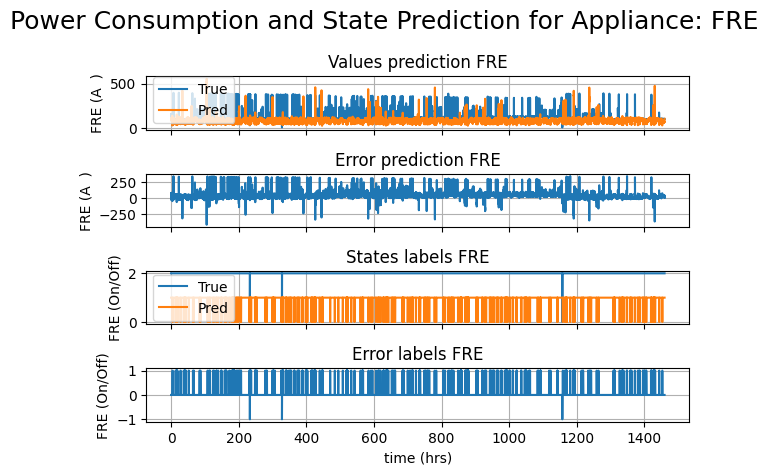

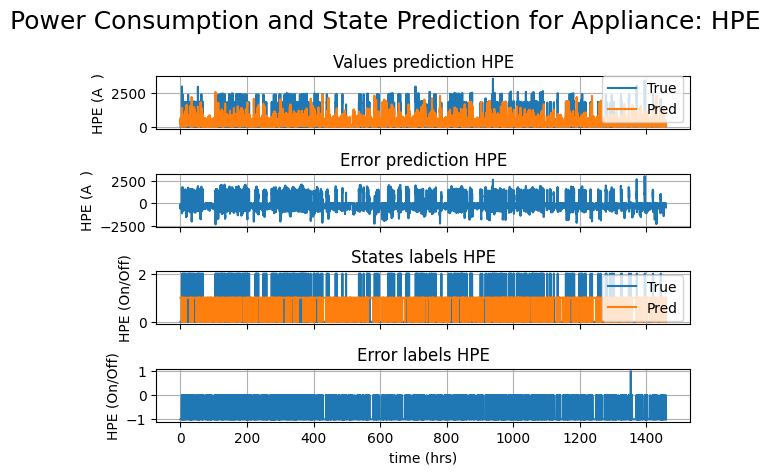

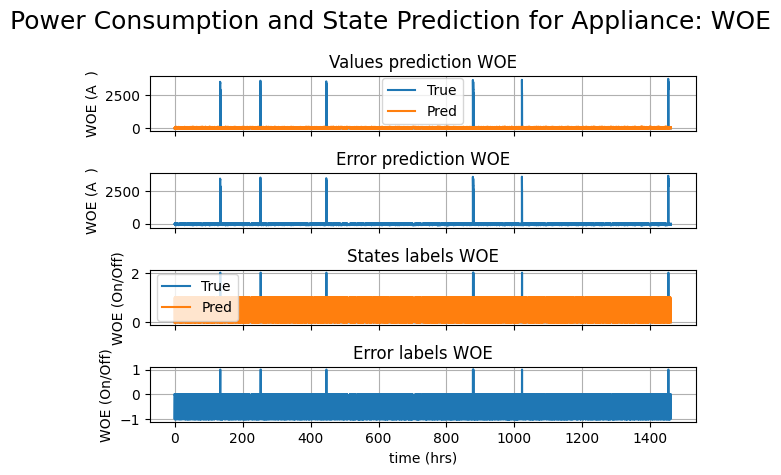

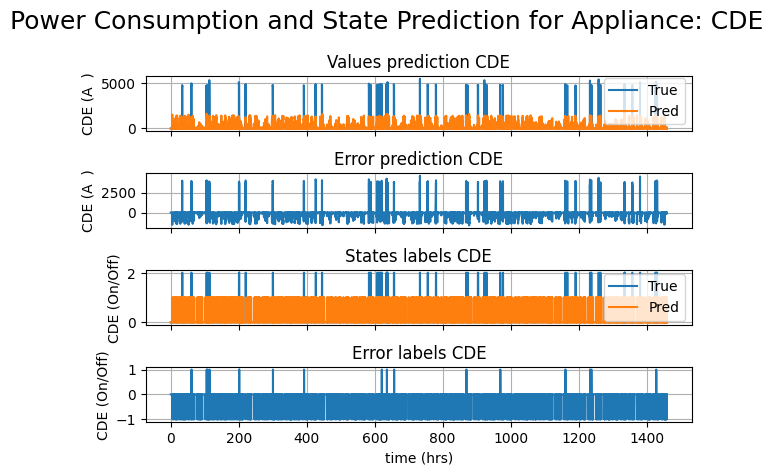

DONE: Running PyDTS (Testing)
DONE: BaseNILM 1-fold simulation


In [22]:
#######################################################################################################################
#######################################################################################################################
# Title:        BaseNILM toolkit for energy disaggregation
# Topic:        Non-intrusive load monitoring utilising machine learning, pattern matching and source separation
# File:         start
# Date:         23.05.2024
# Author:       Dr. Pascal A. Schirmer
# Version:      V.1.0
# Copyright:    Pascal Schirmer
#######################################################################################################################
#######################################################################################################################

#######################################################################################################################
# Import external libs
#######################################################################################################################
# ==============================================================================
# Internal
# ==============================================================================
from src.main import main
from src.optiHyp import optiHyp
from src.optiGrid import optiGrid
from src.general.helpFnc import initPath, initSetup
from mdlPara import mdlPara

# ==============================================================================
# External
# ==============================================================================
import warnings
import os

#######################################################################################################################
# Format
#######################################################################################################################
warnings.filterwarnings("ignore")

#######################################################################################################################
# Paths
#######################################################################################################################
setupPath = initPath('BaseNILM')

#######################################################################################################################
# Init
#######################################################################################################################
[setupExp, setupDat, setupPar, setupMdl] = initSetup()

#######################################################################################################################
# Setup and Configuration
#######################################################################################################################
# ==============================================================================
# Experimental Parameters
# ==============================================================================
# ------------------------------------------
# Names
# ------------------------------------------
setupExp['name'] = 'Default'                                                                                             # Name of the simulation
setupExp['author'] = 'Pascal Schirmer'                                                                                   # Name of the author

# ------------------------------------------
# General
# ------------------------------------------
setupExp['sim'] = 0                                                                                                      # 0) simulation, 1) optimisation hyperparameters, 2) optimising grid
setupExp['gpu'] = 0                                                                                                      # 0) cpu, 1) gpu
setupExp['warn'] = 3                                                                                                     # 0) all msg are logged, 1) INFO not logged, 2) INFO and WARN not logged, 3) disabled

# ------------------------------------------
# Training/Testing
# ------------------------------------------
setupExp['method'] = 0                                                                                                   # 0) 1-fold with data split, 1) k-fold with cross validation, 2) transfer learning with different datasets, 3) id based
setupExp['trainBatch'] = 0                                                                                               # 0) all no batching, 1) fixed batch size (see data batch parameter), 2) id based
setupExp['kfold'] = 10                                                                                                   # number of folds for method 1)
setupExp['train'] = 0                                                                                                    # 0) no training (trying to load model), 1) training new model (or retraining)
setupExp['test'] = 1                                                                                                     # 0) no testing, 1) testing

# ------------------------------------------
# Output Control
# ------------------------------------------
setupExp['save'] = 0                                                                                                     # 0) results are not saved, 1) results are saved
setupExp['log'] = 0                                                                                                      # 0) no data logging, 1) logging input data
setupExp['plot'] = 1                                                                                                     # 0) no plotting, 1) plotting

# ==============================================================================
# Data Parameters
# ==============================================================================
# ------------------------------------------
# General
# ------------------------------------------
setupDat['type'] = 'mat'                                                                                                 # data input type: 1) 'xlsx', 2) 'csv', 3) 'mat', 4) 'pkl', 5) 'h5'
setupDat['freq'] = 'LF'                                                                                                  # 'LF': low-frequency data, 'HF': high-frequency data
setupDat['dim'] = 3                                                                                                      # 2) 2D input data, 3) 3D input data
setupDat['batch'] = 100000                                                                                               # number of samples fed at once to training
setupDat['Shuffle'] = False                                                                                              # False: no shuffling, True: shuffling data when splitting
setupDat['rT'] = 10/12                                                                                                   # training proportion (0, 1)
setupDat['rV'] = 0.2                                                                                                     # validation proportion (0, 1) as percentage from training proportion
setupDat['idT'] = [2]                                                                                                    # list of testing ids for method 3)
setupDat['idV'] = [2]                                                                                                    # list of validation ids for method 3)

# ------------------------------------------
# Datasets
# ------------------------------------------
setupDat['folder'] = 'ampds'                                                                                             # name of the folder for the dataset under \data
setupDat['house'] = 1                                                                                                    # only when loading nilmtk converted files with '.h5' format
setupDat['train'] = ['ampds2']                                                                                           # name of training datasets (multiple)
setupDat['test'] = 'ampds2'                                                                                              # name of testing datasets (one)
setupDat['val'] = 'ampds2'                                                                                               # name of validation dataset (one)

# ------------------------------------------
# Input/ Output Mapping
# ------------------------------------------
setupDat['inp'] = []                                                                                                     # names of the input variables (X), if empty all features are used
setupDat['out'] = ['DWE', 'FRE', 'HPE', 'WOE', 'CDE']                                                                    # names of the output variables (y), if empty all appliances are used
setupDat['outFeat'] = 0                                                                                                  # if data is three-dimensional, the output axis must be defined
setupDat['outEnergy'] = 0.0                                                                                              # 0) appliances are selected based on the list, 1) appliances are selected to capture x % of the total energy

# ------------------------------------------
# Sampling
# ------------------------------------------
setupDat['fs'] = 1/60                                                                                                    # sampling frequency (Hz) for HF data this is the LF output frequency of (y)
setupDat['lim'] = 365*24*60                                                                                              # 0) data is not limited, x) limited to x samples

# ------------------------------------------
# Pre-processing
# ------------------------------------------
setupDat['weightNorm'] = 0                                                                                               # 0) separate normalisation per input/output channel, 1) weighted normalisation
setupDat['inpNorm'] = 3                                                                                                  # normalising input values (X): 0) None, 1) -1/+1, 2) 0/1, 3) avg/sig, 4) Q1/Q3, 5) QT
setupDat['outNorm'] = 2                                                                                                  # normalising output values (y): 0) None, 1) -1/+1, 2) 0/1, 3) avg/sig, 4) Q1/Q3, 5) QT
setupDat['inpNoise'] = 0                                                                                                 # adding gaussian noise (dB) to input
setupDat['outNoise'] = 0                                                                                                 # adding gaussian noise (dB) to output
setupDat['inpFil'] = 0                                                                                                   # filtering input data (X): 0) None, 1) Median
setupDat['outFil'] = 0                                                                                                   # filtering output data (y): 0) None, 1) Median
setupDat['inpFilLen'] = 61                                                                                               # filter length input data (samples)
setupDat['outFilLen'] = 61                                                                                               # filter length output data (samples)
setupDat['threshold'] = 50                                                                                               # 0) no threshold x) threshold to transform regressio into classification data
setupDat['balance'] = 0                                                                                                  # 0) no balancing 1) balancing based classes (classification), 2) balancing based on threshold (regression)
setupDat['ghost'] = 0                                                                                                    # 0) ghost data will not be used, 1) ghost data will be treated as own appliance, 2) ideal data will be used (only if X is 1D and has equal domain to y)

# ==============================================================================
# General Parameters
# ==============================================================================
# ------------------------------------------
# Solver
# ------------------------------------------
setupPar['method'] = 0                                                                                                   # 0) regression, 1) classification
setupPar['solver'] = 'TF'                                                                                                # TF: Tensorflow, PT: PyTorch, SK: sklearn, PM: Pattern Matching, SS: Source Separation and CU: Custom (placeholder for own ideas)
setupPar['model'] = 'CNN'                                                                                                # possible classifier: 1) ML: RF, CNN, LSTM \ 2) PM: DTW, MVM \ 3) SS: NMF, SCA
setupPar['modelInpDim'] = 3                                                                                              # model input dimension 3D or 4D (e.g. for CNN2D)

# ------------------------------------------
# Framing and Features
# ------------------------------------------
setupPar['frame'] = 1                                                                                                    # 0) no framing, 1) framing
setupPar['feat'] = 0                                                                                                     # 0) raw data values, 1) statistical features (frame based), 2) statistical features (input based), 3) input and frame based features, 4) 2D features
setupPar['window'] = 20                                                                                                  # window length (samples)
setupPar['overlap'] = 19                                                                                                 # overlap between consecutive windows (no overlap during test if -1)
setupPar['outseq'] = 0                                                                                                   # 0) seq2point, x) length of the subsequence in samples
setupPar['yFocus'] = 10                                                                                                  # focus point for seq2point (average if -1)
setupPar['nDim'] = 2                                                                                                     # input dimension for model 1D (1), 2D (2), or 3D (3)

# ------------------------------------------
# Postprocessing
# ------------------------------------------
setupPar['ranking'] = 1                                                                                                  # 0) no feature ranking, 1) feature ranking using random forests
setupPar['outMin'] = 0                                                                                                   # limited output values (minimum)
setupPar['outMax'] = 5500                                                                                                # limited output values (maximum)

# ==============================================================================
# Model Parameters
# ==============================================================================
setupMdl = mdlPara(setupMdl)


#######################################################################################################################
# Calculations
#######################################################################################################################
# ==============================================================================
# Warnings
# ==============================================================================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = str(setupExp['warn'])

# ==============================================================================
# Model Parameters
# ==============================================================================
if setupExp['sim'] == 0:
    main(setupExp, setupDat, setupPar, setupMdl, setupPath)

# ==============================================================================
# Optimising Hyperparameters
# ==============================================================================
if setupExp['sim'] == 1:
    optiHyp(setupExp, setupDat, setupPar, setupMdl, setupPath)

# ==============================================================================
# Optimising Grid
# ==============================================================================
if setupExp['sim'] == 2:
    optiGrid(setupExp, setupDat, setupPar, setupMdl, setupPath)


----------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------
Welcome to BaseNILM: A toolkit for energy disaggregation
Mode:       Simulation
Author:     Dr. Pascal A. Schirmer
Copyright:  Pascal Schirmer
Version:    v.0.2
Date:       21.11.2023
----------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------
START: BaseNILM 1-fold simulation
------------------------------------------
START: Loading testing data
------------------------------------------
INFO: Loading Dataset
INFO: Loading dataset from sub-folder: \data\ redd
ERROR: 3D error data file could not be loaded
INFO: Mat data file loaded
INFO: Selecting output features failed
INFO: Data limited to  525600  samples
INFO: Loading Da

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_120 (Conv1D)             │ (None, 20, 30)         │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_121 (Conv1D)             │ (None, 20, 30)         │         7,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_122 (Conv1D)             │ (None, 20, 40)         │         7,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_123 (Conv1D)             │ (None, 20, 50)         │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_124 (Conv1D)             │ (None, 20, 50)         │        12,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 4, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 256)            │        51,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,895 (878.50 KB)

 Trainable params: 224,895 (878.50 KB)

 Non-trainable params: 0 (0.00 B)

INFO: Model loaded
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
INFO: Total inference time (ms): 489.29
INFO: Inference time per sample (us): 112.20
INFO: Model size (kB): 0.01


------------------------------------------
START: Postprocessing
------------------------------------------
INFO: Start Postprocessing Prediction
INFO: Normalise data
INFO: Input Avg/Sig normalisation
INFO: Output 0/1 normalisation
INFO: Normalise data
INFO: Input Avg/Sig normalisation
INFO: Output 0/1 normalisation


------------------------------------------
START: Output
------------------------------------------
INFO: Calculating Performance
INFO: Ranking Input Features
INFO: Running Feature Ranking
INFO: Printing results on console
INFO: Simulation completed with 0 low priority and 0 high priority warnings
INFO: List of low priority warnings includes:
INFO: List of high priority warnings includes:
INFO: Printing accuracy results
---------------------------------------------------------------------------------

IndexError: list index out of range

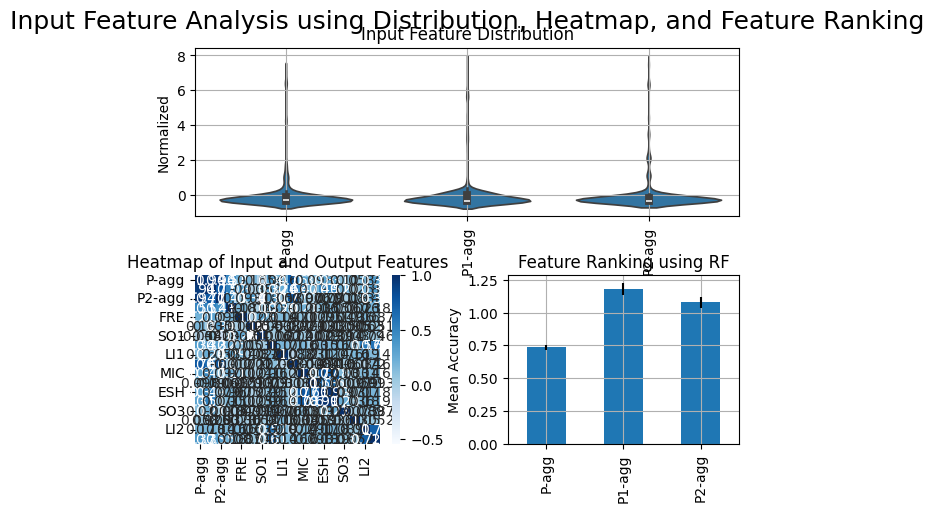

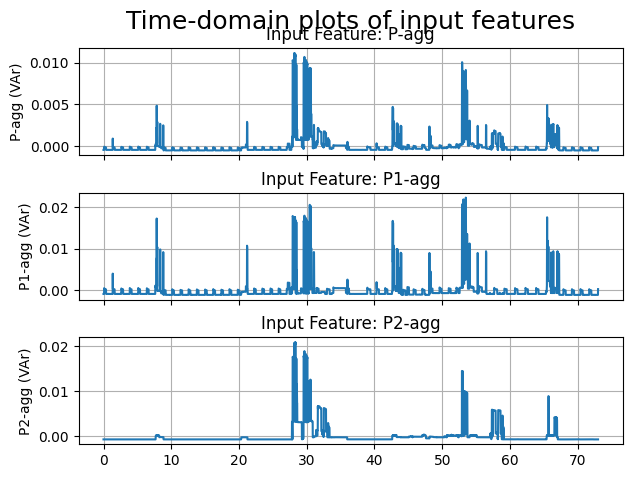

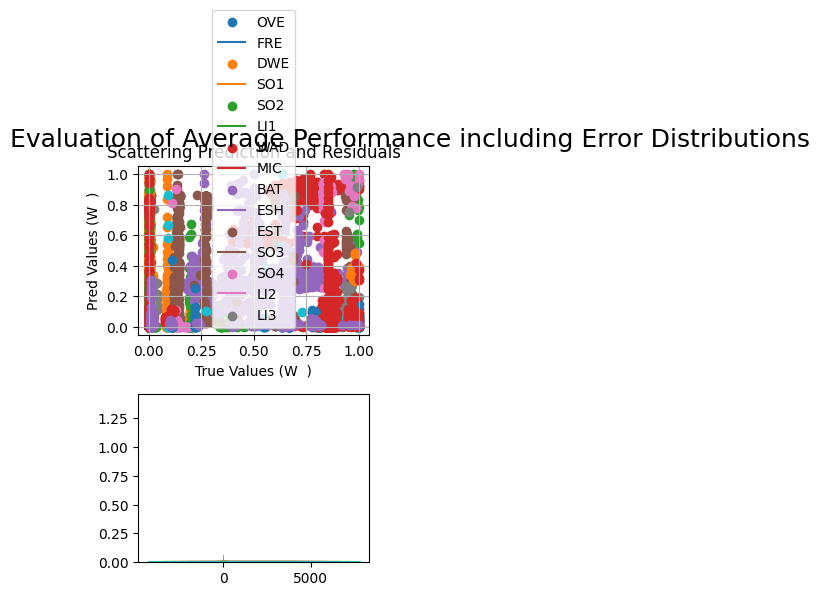

In [23]:
setupExp['name'] = 'CNN_Redd'                                                                                             # Name of the simulation
setupExp['train'] = 0
setupPar['model'] = 'CNN' 

setupExp['save'] = 1                                                                                               # 0) results are not saved, 1) results are saved
setupExp['log'] = 1   

setupDat['folder'] = 'redd'                                                                                             # name of the folder for the dataset under \data
setupDat['house'] = 1                                                                                                  # only when loading nilmtk converted files with '.h5' format
setupDat['train'] = ['redd1']                                                                                           # name of training datasets (multiple)
setupDat['test'] = 'redd1'                                                                                              # name of testing datasets (one)
setupDat['val'] = 'redd1'                                                                                               # name of validation dataset (one)

setupDat['out'] = ['OVE', 'FRE', 'DWE', 'SO1', 'SO2', 'LT1','WAD', 'MIC', 'BAT', 'ESH', 'EST', 'SO3', 'SO4', 'LI2', 'LI3']

main(setupExp, setupDat, setupPar, setupMdl, setupPath)
